# Exercise 1

Consider the points P1 = (2, 0), P2 = (0, 3), P3 = (−4, 0), P4 = (4, 2), P5 = (5, 1). Specify
the tests to be performed, when Jarvis March algorithm is applied, for determining the
successor M of the &quot;leftmost&quot; point and of M&#39;s successor. How do the tests proceed if it starts
with &quot;the lowest&quot; point?

\
**Solution:**

1. **Ortientation Test**  
To determine if three points $p, q$ and $r$ form a counter clockwise turn we calculate the following value:
$val = (q.y - p.y) \times (r.x - q.x) - (q.x - p.x) \times (r.y - q.y)$

Then we check the value of val:
- If $val = 0$ then the pointsa re collinear
- If $val > 0$ then the points form a clockwise turn
- If $val < 0$ the points form a counterclockwise turn

2. **Starting with the leftmost point** \
The algorithm begins by finding the point with the minimum x coordinate.
Then, we initialize our potential successor $q$ as any other point. We then iterte through the reminaing points $i$ to see if $(p, i, q)$ is counter clockwise using the formula shown above. This is for determining the successor $M$ of the leftmost point. \
\
The following step is determining the successor of $M$. We let $p$ equal to the rightmost point.

3. **Starting with the lowest point**  
If the algorithm start with the lowest y coordinate then the leftmost point and the righmost of lowest point and the leftmost of lowest point are tied.
We start at the leftmose lowest point and the tests proceed exactly as detailed above and then we proceed with the rightmost of lowest point. We find the successor of it and then the successor of that successor by setting $p$ equal to that point $P_i$, finding the orientation, making the other point a candidate, checking the orientation of the leftmost of lowest point.

These test continue similarly until the starting point is reached.







---



# Exercise 2

Consider the set M = {P1, P2, ..., P7}, where P1 = (1, 11), P2 = (2, 7), P3 = (3, 8), P4 = (4,
10), P5 = (5, 7), P6 = (6, 7), P7 = (7, 11). Detail how the evolution of the vertices during the
determination of the lower edge of the border of the convex hull for M is obtained during
Graham&#39;s scan / Andrew variant of Graham&#39;s scan.


\
**Solution:**

The points in the exercise are in increasing order of the $x$ coordinate.\
In the evolution of the lower hull, the algorithm maintains a tack of vertices and for each new point, it checks the orientation fo the last two points in the stack and the new point. A point is accepted only if it forms a counter clockwise turn. \
The orientation value is calculated as: \
$val = (q.y - p.y) \times (r.x - q.x) - (q.x - p.x) \times (r.y - q.y)$ \
Just like in exercise 1, the value of $val$ determines the orientation of the turn.
For each step we take in the point in the order it was given to us in the set and we perform an orientation test on it. If it is a counter clockwise turn then we add and if it's a clock wise one, we pop one point from the stack until we are left with the last points. \
These last points form the lower edge of the convex hull.




---



# Exercise 3

Generate at least 40 random 2D points. Compute the convex hull using the Quickhull
algorithm, outputting the hull vertices in clockwise order. Verify the result by computing the hull
again with Andrew’s monotone chain and checking that both algorithms produce the same hull
vertex set.

\
**Solution:**

I will compute it using a Python implementation of the two algorithms.

Quickhull found 10 vertices.
Andrew's Chain found 10 vertices.
Both algorithms produce the same hull vertex set: True


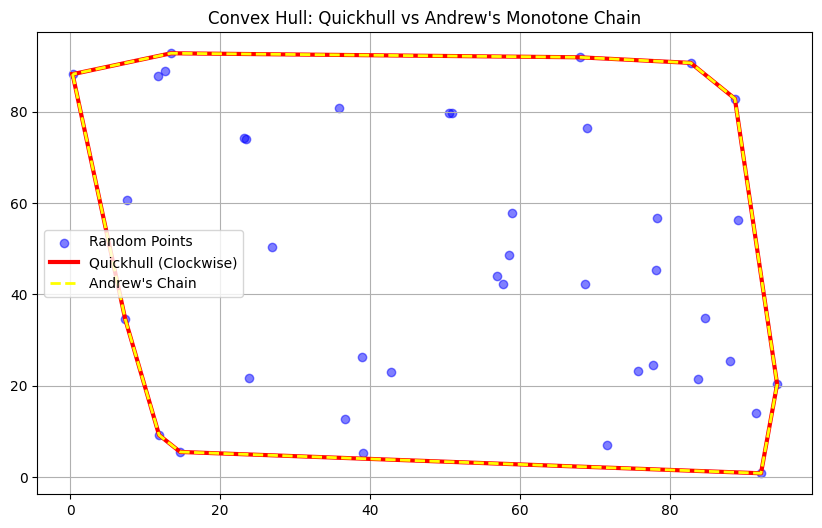

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

num_points = 40
points = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(num_points)]

def is_left(a, b, p):
    # this is the formula shown in the previous exercises
    return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0]) > 0

def get_farthest(a, b, subset):
    # yhis will find the point that maximizes the perpendicular distance to line a-b
    return max(subset, key=lambda p: abs((b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0])))

def quickhull_recurse(a, b, subset):
    if not subset: return []
    farthest = get_farthest(a, b, subset)
    s1 = [p for p in subset if is_left(a, farthest, p)]
    s2 = [p for p in subset if is_left(farthest, b, p)]
    return quickhull_recurse(a, farthest, s1) + [farthest] + quickhull_recurse(farthest, b, s2)

def quickhull(points):
    if len(points) < 3:
        return points

    # this is to find the leftmost and rightmost points
    min_x = min(points, key=lambda p: p[0])
    max_x = max(points, key=lambda p: p[0])
    s1 = [p for p in points if is_left(min_x, max_x, p)]
    s2 = [p for p in points if is_left(max_x, min_x, p)]
    return [min_x] + quickhull_recurse(min_x, max_x, s1) + [max_x] + quickhull_recurse(max_x, min_x, s2)

def andrews_monotone_chain(points):
    points = sorted(points, key=lambda p: (p[0], p[1]))
    if len(points) <= 2:
        return points

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    # builds lower hull
    lower = []
    for p in points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    # bulds upper hull
    upper = []
    for p in reversed(points):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return lower[:-1] + upper[:-1]

qh_hull = quickhull(points)
am_hull = andrews_monotone_chain(points)

sets_match = set(qh_hull) == set(am_hull)
print(f"Quickhull found {len(qh_hull)} vertices.")
print(f"Andrew's Chain found {len(am_hull)} vertices.")
print(f"Both algorithms produce the same hull vertex set: {sets_match}")

# visaulization generated by Gemini
plt.figure(figsize=(10, 6))


x_vals, y_vals = zip(*points)
plt.scatter(x_vals, y_vals, color='blue', label='Random Points', alpha=0.5)


qh_closed = qh_hull + [qh_hull[0]] # Close the polygon
qx, qy = zip(*qh_closed)
plt.plot(qx, qy, color='red', linewidth=3, label='Quickhull (Clockwise)')


am_closed = am_hull + [am_hull[0]] # Close the polygon
ax, ay = zip(*am_closed)
plt.plot(ax, ay, color='yellow', linestyle='dashed', linewidth=2, label="Andrew's Chain")

plt.title("Convex Hull: Quickhull vs Andrew's Monotone Chain")
plt.legend()
plt.grid(True)
plt.show()




---



# Exercise 4
Randomly generate at least 50 distinct 2D points. Implement a divide-and-conquer convex
hull algorithm. Output the final hull vertices in counterclockwise order.

\
**Solution:**

Computed Convex Hull with 9 vertices in Counter-Clockwise order:
(14, 97)
(2, 90)
(1, 74)
(1, 41)
(23, 11)
(38, 5)
(93, 2)
(97, 29)
(95, 99)


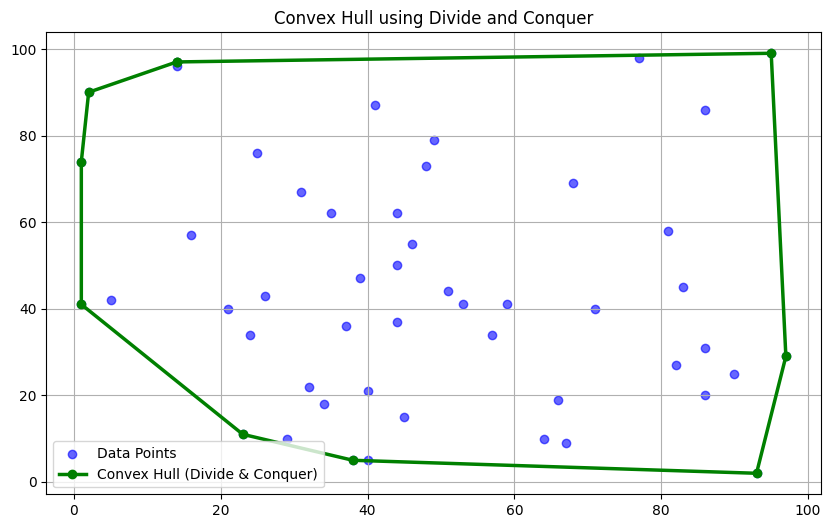

In [ ]:
import random
import matplotlib.pyplot as plt

def ccw(p, q, r):
    return (q[0] - p[0]) * (r[1] - p[1]) - (q[1] - p[1]) * (r[0] - p[0])

def base_case_hull(points):
    # we use a mini monotone chain to guarantee strict counter clockwise order
    points = sorted(points)
    if len(points) <= 2:
        return points
    lower = []
    for p in points:
        while len(lower) >= 2 and ccw(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(points):
        while len(upper) >= 2 and ccw(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return lower[:-1] + upper[:-1]

def merge_hulls(a, b):
    n1, n2 = len(a), len(b)
    ia = max(range(n1), key=lambda i: a[i][0])
    ib = min(range(n2), key=lambda i: b[i][0])

    inda, indb = ia, ib
    done = False
    while not done:
        done = True
        # moves inda counter clockwise and indb clockwise
        while ccw(b[indb], a[inda], a[(inda + 1) % n1]) <= 0:
            inda = (inda + 1) % n1
        while ccw(a[inda], b[indb], b[(indb - 1) % n2]) >= 0:
            indb = (indb - 1) % n2
            done = False

    upper_a, upper_b = inda, indb
    inda, indb = ia, ib
    done = False
    while not done:
        done = True
        # moves indb counter clockwiseand inda clockwise
        while ccw(a[inda], b[indb], b[(indb + 1) % n2]) <= 0:
            indb = (indb + 1) % n2
        while ccw(b[indb], a[inda], a[(inda - 1) % n1]) >= 0:
            inda = (inda - 1) % n1
            done = False

    lower_a, lower_b = inda, indb

    #this combines hulls in counter clock wise order
    res = []
    ind = upper_a
    res.append(a[upper_a])
    while ind != lower_a:
        ind = (ind + 1) % n1
        res.append(a[ind])

    ind = lower_b
    res.append(b[lower_b])
    while ind != upper_b:
        ind = (ind + 1) % n2
        res.append(b[ind])
    return res

# this is the divide and conquer recursive function
def divide_and_conquer_hull(points):
    if len(points) <= 5:
        return base_case_hull(points)

    mid = len(points) // 2
    left_hull = divide_and_conquer_hull(points[:mid])
    right_hull = divide_and_conquer_hull(points[mid:])

    return merge_hulls(left_hull, right_hull)

num_points = 50
points_set = set()
while len(points_set) < num_points:
    points_set.add((random.randint(0, 100), random.randint(0, 100)))
points = sorted(list(points_set)) # sort by x coord initially
hull = divide_and_conquer_hull(points)

print(f"Computed Convex Hull with {len(hull)} vertices in Counter-Clockwise order:")
for vertex in hull:
    print(vertex)

# visualization generated by Gemini
plt.figure(figsize=(10, 6))
x_vals, y_vals = zip(*points)
plt.scatter(x_vals, y_vals, color='blue', label='Data Points', alpha=0.6)
hull_closed = hull + [hull[0]]
hx, hy = zip(*hull_closed)

plt.plot(hx, hy, color='green', linewidth=2.5, marker='o', label='Convex Hull (Divide & Conquer)')
plt.title("Convex Hull using Divide and Conquer")
plt.legend()
plt.grid(True)
plt.show()